# Continuous Variables Tutorial: The Wigner Function

## 1. Introduction

In this tutorial, we will explore the concept of the Wigner function, a powerful tool that can be used to visualise different quantum states of a system (or a **phase space**).

## 2. Setup

For this tutorial, we will be using several libraries to help us visualise and analyse the Wigner function. We will also be defining some constants:
- `N`: Hilbert space cutoff we will be setting this to a managable number, but the size of this number is dependent on your system, but it can be infinite.
- `PHASE_SPACE_GRID`: The phase space grid simply defines the range of values for the phase space coordinates (x and p).

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import qutip as qt

N = 20
PHASE_SPACE_GRID = np.linspace(-5, 5, 200)

## 3. Phase Space and the Wigner Function

### 3.1. Phase Space

In classical physics, we often describe an oscillating system as having the properties:
- **position** ($x$)
- **momentum** ($p$)

For example, if we take a simple demonstration of a weight on a spring, when the position ($x$) of the weight oscillates between two extremes, the momentum also changes ($p$) in response to a force (for instance, gravity).

When plotted against time, this is shown as a cosine wave.

<div align="center">
    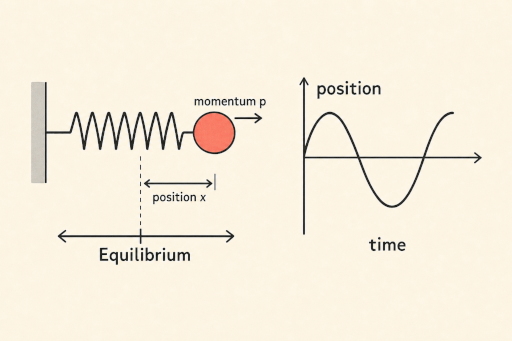
</div>

When we want to describe where a quantum particle is and how fast it is moving, in classical physics, we would just say: "It is at position x with momentum p." However, in quantum mechanics, you cannot just pin down both position and momentum at the same time because of the [Heisenberg Uncertainty principle](#41-heisenberg-uncertainty-principle-). So instead of a single point, a quantum state is more like a cloud spread out over a map where one axis is position and the other is momentum. This "cloud" of space is what we refer to as the **phase space**.

We can visualise this **phase space** as a plot of position ($x$) against momentum ($p$):

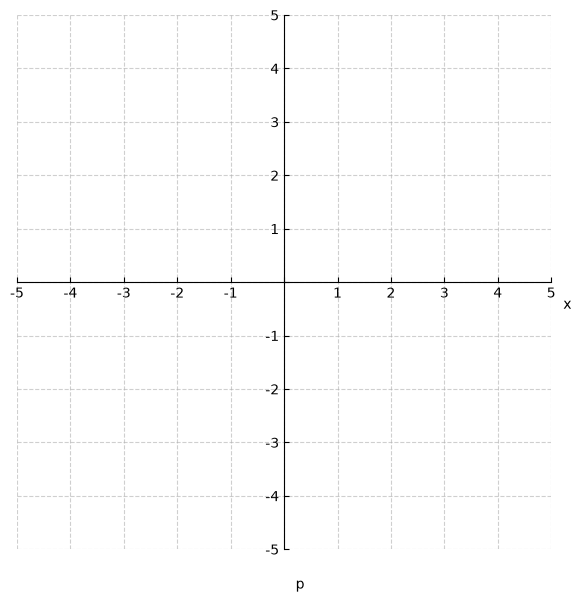

In [2]:
def _hide_zero(value, _) -> str:
    return "" if np.isclose(value, 0) else f"{value:g}"

def plot_phase_space(
    state: qt.Qobj | None = None,
    title: str | None = None,
) -> None:
    fig, axis = plt.subplots(figsize=(6, 6))

    axis.set_xlim(PHASE_SPACE_GRID[0], PHASE_SPACE_GRID[-1])
    axis.set_ylim(PHASE_SPACE_GRID[0], PHASE_SPACE_GRID[-1])

    ticks = np.linspace(-5, 5, 11)
    axis.set_xticks(ticks)
    axis.xaxis.set_major_formatter(ticker.FuncFormatter(_hide_zero))
    axis.set_yticks(ticks)
    axis.yaxis.set_major_formatter(ticker.FuncFormatter(_hide_zero))

    axis.spines["left"].set_position("zero")
    axis.spines["bottom"].set_position("zero")

    # hide outer frame
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    # Put tick marks on the inner axes and point them inward
    axis.tick_params(
        axis="both",
        direction="in",
        right=False,
        top=False,
        which="both",
    )

    axis.grid(True, linestyle="--", alpha=0.6)

    # add labels
    axis.set_xlabel("x")
    axis.xaxis.set_label_coords(1.03, 0.47)
    axis.set_ylabel("p", rotation=0)
    axis.yaxis.set_label_coords(0.53, -0.08)

    # add the phase state
    if state is not None:
        vmax = np.max(np.abs(state)) * 0.9
        axis.contourf(
            PHASE_SPACE_GRID,
            PHASE_SPACE_GRID,
            state,
            200,
            cmap="RdBu_r",
            vmin=-vmax,
            vmax=vmax
        )

    if title is not None:
        axis.set_title(title, fontsize=14, fontweight="bold")

    axis.set_aspect("equal", adjustable="box")

    plt.tight_layout()
    plt.show()

plot_phase_space(title="Empty Phase Space")

### 3.2. The Wigner Function

The Wigner function is a way to visualise the phase space. If we think of it like a weather map for quantum states: it assigns a number to every point in phase space, telling you something about how likely the particle is to be found there. The colors in our plots work like this: red and yellow areas are where the state "likes to hang out" (positive values), while blue areas are strange—they represent negative values, which is something you'd never see in a normal probability map. Those blue regions are a smoking gun for quantum weirdness; they're impossible in classical physics and signal that quantum interference is happening.

For a quantum state with wavefunction $\psi(x)$, the Wigner function is computed as:

$$W(x, p) = \frac{1}{\pi \hbar} \int_{-\infty}^{\infty} \psi^*(x + y) \, \psi(x - y) \, e^{2ipy/\hbar} \, dy$$

This formula takes the wavefunction at two nearby positions (x+y and x−y), multiplies them together, and performs a Fourier transform to extract the momentum information at each point in phase space.

Even though the Wigner function can dip below zero in some places, it still behaves like a proper probability distribution overall as the total "amount" across the entire phase space adds up to exactly 1.

#### 3.2.1. Example: The Vacuum State

The **vacuum state** or the "ground" state is the lowest-energy state of a harmonic oscillator and is usually represented as $|0\rangle$.

As a Wigner plot in phase space, it appears a symmetric, circular Gaussian blob centered at $(x=0, p=0)$ and is the most compact state in quantum mechanics.

What is interesting is that you will notice that despite being the lowest state, the plot is not exactly zero, this is because the "blob" represents quantum fluctuations.

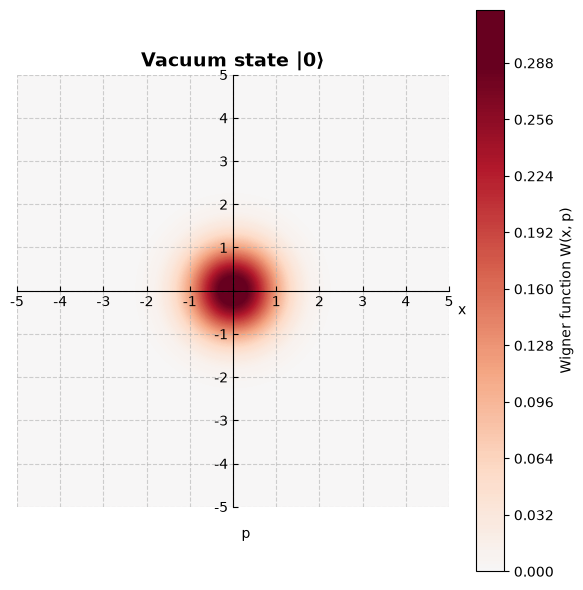

In [3]:
# use qutip to calculate the wigner function of vacuum space (0)
wigner_function = qt.wigner(qt.basis(N, 0), PHASE_SPACE_GRID, PHASE_SPACE_GRID)

plot_phase_space(state=wigner_function, title="Wigner function W(x, p) of vacuum state |0⟩")

## 4. Appendix

### 4.1. Heisenberg Uncertainty Principle